# Iris Flower Classification using Machine Learning

## Oasis Infobyte Data Science Internship

### Task 1

### Objective

The objective of this project is to build a machine learning model that classifies Iris flowers into one of three species:

- Setosa
- Versicolor
- Virginica

using four flower measurements:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

The project includes:

- Exploratory Data Analysis (EDA)
- Data Visualization
- Model Training
- Model Evaluation
- Model Comparison

In [1]:
# ================================
# Import Required Libraries
# ================================

# For working with tables (DataFrames)
import pandas as pd

# For mathematical operations
import numpy as np

# For creating graphs
import matplotlib.pyplot as plt

# For beautiful statistical graphs
import seaborn as sns

# Load the Iris dataset
from sklearn.datasets import load_iris

# Split data into training and testing
from sklearn.model_selection import train_test_split

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Display graphs inside the notebook
%matplotlib inline

In [2]:
# ================================
# Load the Iris Dataset
# ================================

# Load the dataset
iris = load_iris()

# Convert the data into a DataFrame (table)
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add the flower species as a new column
df["species"] = iris.target

# Display the first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
# ================================
# Replace Numbers with Flower Names
# ================================

# Convert numeric labels to flower names
df["species"] = df["species"].replace({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

# Display the first 5 rows again
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [4]:
# ================================
# Basic Information About the Dataset
# ================================

# Number of rows and columns
print("Shape of the dataset:")
print(df.shape)

print("\n---------------------------\n")

# Column names
print("Column Names:")
print(df.columns)

print("\n---------------------------\n")

# Data types of each column
print("Data Types:")
print(df.dtypes)

print("\n---------------------------\n")

# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

Shape of the dataset:
(150, 5)

---------------------------

Column Names:
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species'],
      dtype='str')

---------------------------

Data Types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object

---------------------------

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


In [5]:
# ================================
# Statistical Summary of the Dataset
# ================================

# Display statistical information
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
# ================================
# Count Flowers in Each Species
# ================================

df["species"].value_counts()

species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64

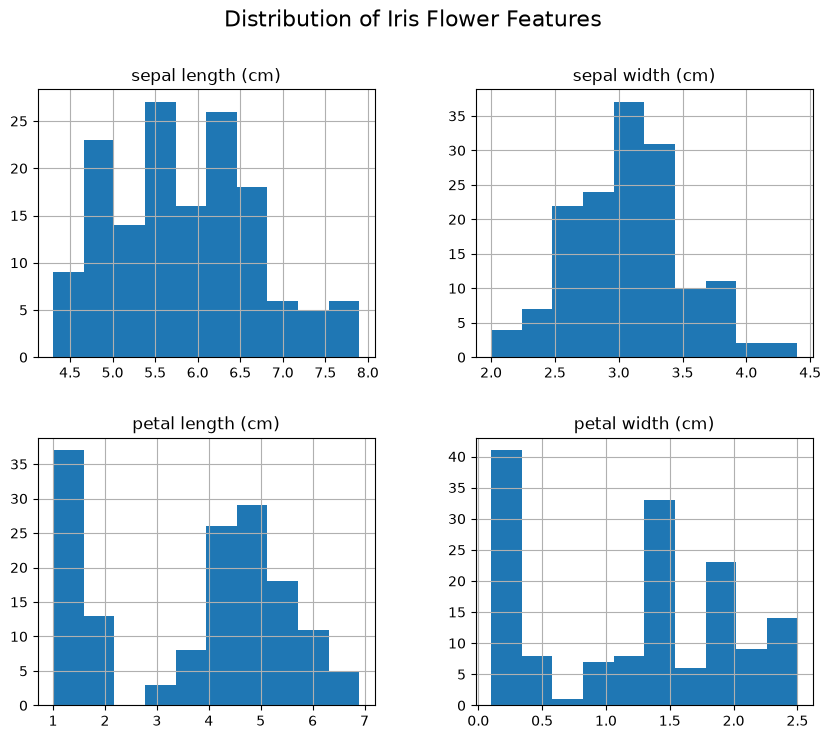

In [7]:
# ================================
# Histogram of All Numerical Features
# ================================

# Create histograms
df.hist(figsize=(10, 8))

# Add a title
plt.suptitle("Distribution of Iris Flower Features", fontsize=16)

# Display the graph
plt.show()

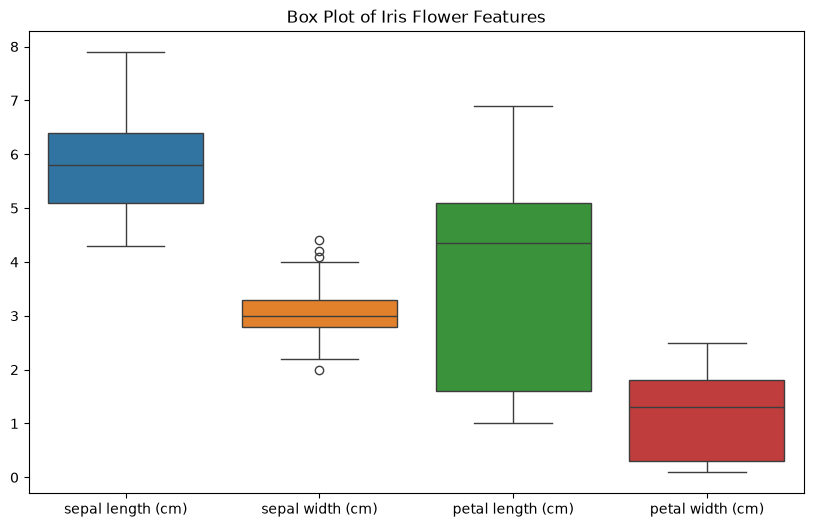

In [8]:
# ================================
# Box Plot of Numerical Features
# ================================

# Create the figure
plt.figure(figsize=(10, 6))

# Draw the box plot
sns.boxplot(data=df.drop("species", axis=1))

# Add title
plt.title("Box Plot of Iris Flower Features")

# Display the graph
plt.show()

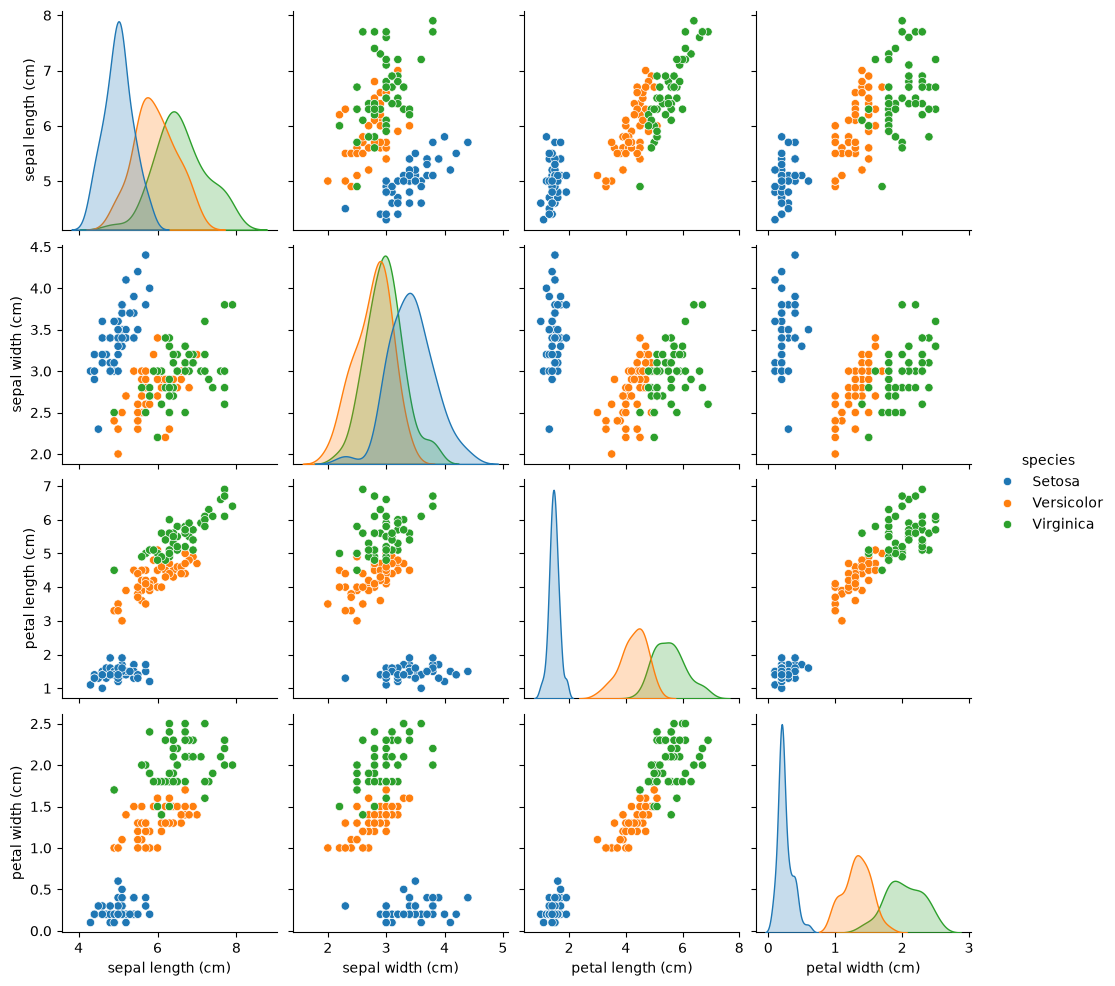

In [9]:
# ================================
# Pair Plot
# ================================

# Create a pair plot
sns.pairplot(df, hue="species")

# Display the graph
plt.show()

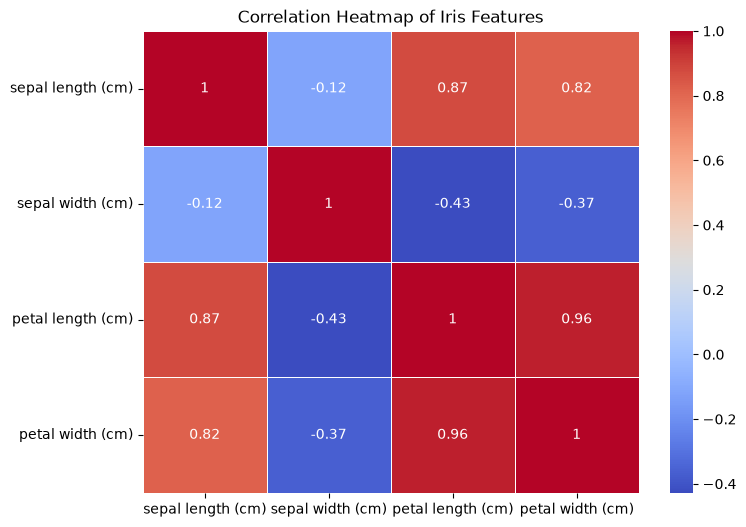

In [10]:
# ================================
# Correlation Heatmap
# ================================

# Select only numerical columns
numeric_df = df.drop("species", axis=1)

# Create the figure
plt.figure(figsize=(8, 6))

# Draw the heatmap
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

# Add title
plt.title("Correlation Heatmap of Iris Features")

# Display the graph
plt.show()

In [11]:
# ================================
# Prepare Data for Machine Learning
# ================================

# Features (Input)
X = iris.data

# Target (Output)
y = iris.target

# Display the shapes
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (150, 4)
Target Shape: (150,)


In [12]:
# ================================
# Split Dataset into Training and Testing Sets
# ================================

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display the shapes
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Labels  :", y_train.shape)
print("Testing Labels   :", y_test.shape)


Training Features: (120, 4)
Testing Features : (30, 4)
Training Labels  : (120,)
Testing Labels   : (30,)


In [13]:
# ================================
# Train Logistic Regression Model
# ================================

# Create the model
logistic_model = LogisticRegression(max_iter=200)

# Train the model
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [14]:
# ================================
# Make Predictions
# ================================

# Predict species for the test data
y_pred = logistic_model.predict(X_test)

# Display the first 10 predictions
print("Predicted Values:")
print(y_pred[:10])

print("\nActual Values:")
print(y_test[:10])

Predicted Values:
[1 0 2 1 1 0 1 2 1 1]

Actual Values:
[1 0 2 1 1 0 1 2 1 1]


In [15]:
# ================================
# Calculate Accuracy
# ================================

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Display accuracy
print("Accuracy of Logistic Regression Model:", accuracy)

Accuracy of Logistic Regression Model: 1.0


In [16]:
# ================================
# Confusion Matrix
# ================================

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display it
print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


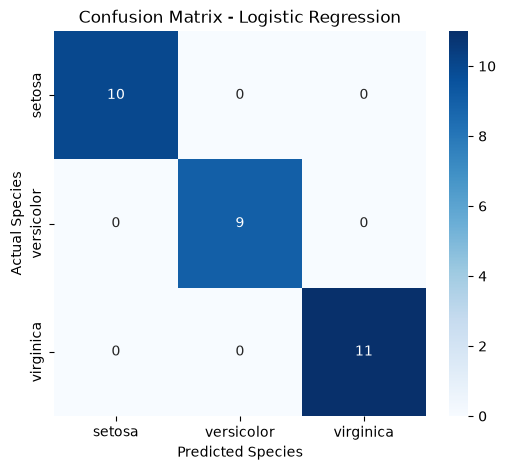

In [17]:
# ================================
# Confusion Matrix Heatmap
# ================================

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [18]:
# ================================
# Classification Report
# ================================

print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [19]:
# ================================
# Train KNN Model
# ================================

# Create KNN model
knn_model = KNeighborsClassifier(n_neighbors=3)

# Train the model
knn_model.fit(X_train, y_train)

print("KNN Model trained successfully!")

KNN Model trained successfully!


In [20]:
# ================================
# Evaluate KNN Model
# ================================

# Make predictions
knn_predictions = knn_model.predict(X_test)

# Calculate accuracy
knn_accuracy = accuracy_score(y_test, knn_predictions)

print("Accuracy of KNN Model:", knn_accuracy)

Accuracy of KNN Model: 1.0


In [21]:
# ================================
# Compare Models
# ================================

print("Model Comparison")
print("---------------------------")
print(f"Logistic Regression Accuracy : {accuracy:.4f}")
print(f"KNN Accuracy                 : {knn_accuracy:.4f}")

if accuracy > knn_accuracy:
    print("\nLogistic Regression performed better.")
elif knn_accuracy > accuracy:
    print("\nKNN performed better.")
else:
    print("\nBoth models achieved the same accuracy.")

Model Comparison
---------------------------
Logistic Regression Accuracy : 1.0000
KNN Accuracy                 : 1.0000

Both models achieved the same accuracy.


# Conclusion

In this project, the Iris Flower dataset was analyzed using Exploratory Data Analysis (EDA) and various visualizations such as histograms, box plots, pair plots, and a correlation heatmap. Two machine learning models, Logistic Regression and K-Nearest Neighbors (KNN), were trained and evaluated.

Both models achieved high accuracy in classifying Iris flowers based on sepal and petal measurements. This project demonstrates the complete machine learning workflow, from data preprocessing and visualization to model training and evaluation, making it a successful solution for the Iris Flower Classification task.